In [1]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

from blackhole.constants import (
    M_sun,
)
from blackhole.irradiation import (
    Epsilon_irr,
    alpha_visc_irr,
)
from blackhole.viscosity import alpha_visc

# Simulation parameters
M_star = M_sun * 9
M_dot = 1e17
a_const = 7.5657e-15

In [2]:
example_Tc = np.linspace(1e3, 6e4)
example_al = alpha_visc(example_Tc)

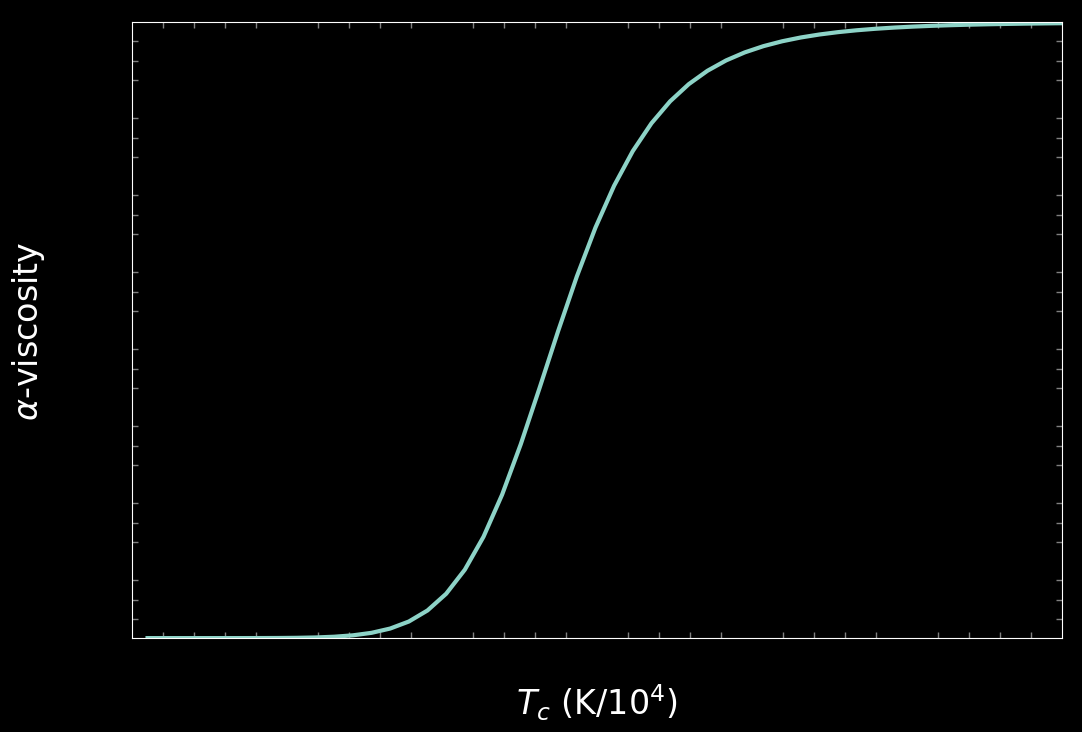

In [3]:
font = {'weight' : 'normal',
        'size'   : 24}
    
plt.rc('font', **font)
def plot_alphat(T_c, alpha_v):
    plt.figure(figsize=(12, 8))
    plt.plot(T_c / 1e4, alpha_v, linewidth=3)
    plt.xlabel(r'$T_c$ (K/$10^4$)')
    plt.ylabel(r'$\alpha$-viscosity')
    plt.minorticks_on()
    plt.tick_params(axis='both', which='major', direction='in', length=8, width=1, colors='black')
    plt.tick_params(axis='both', which='minor', direction='in', length=4, width=1, colors='gray')
    plt.tick_params(axis='both', which='both', top=True, right=True, direction='in')
    plt.tick_params(labeltop=False, labelright=False)  # Hide labels on top and right
    plt.xlim(0, 6)
    plt.ylim(0.04, 0.2)
    plt.show()

# Call the plotting function
plot_alphat(example_Tc, example_al)

    ![png](../../graphs/output_2_0.png)    

In [4]:
# Set up test arrays for irradiation demo
r = np.linspace(1e3, 1e10, 50)
Sigma = np.full(1000, 1e1)
nu = np.full(1000, 1e10)

# Compute irradiation parameter using package functions
eps_irr = Epsilon_irr(Sigma[1], nu[1], r[1], r, M_star, M_dot)

In [5]:
a2 = alpha_visc_irr(example_Tc, eps_irr[0], r[0], M_star)

C:\blackhole\blackhole\src\blackhole\irradiation.py:91: RuntimeWarning: overflow encountered in scalar power
  a2 = r10(r) ** (-0.05 * eps_irr)
C:\blackhole\blackhole\src\blackhole\irradiation.py:100: RuntimeWarning: overflow encountered in scalar power
  a4 = r10(r) ** (0.05 - 0.12 * eps_irr)


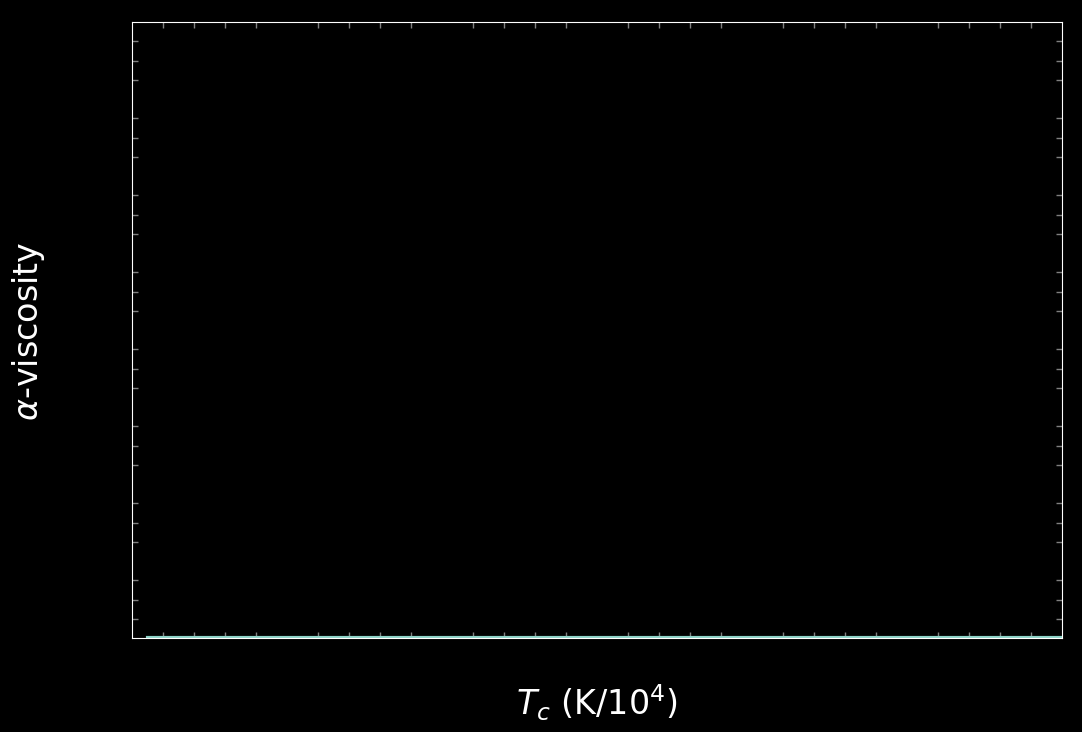

In [6]:
plot_alphat(example_Tc,a2)

    ![png](../../graphs/output_5_0.png)    

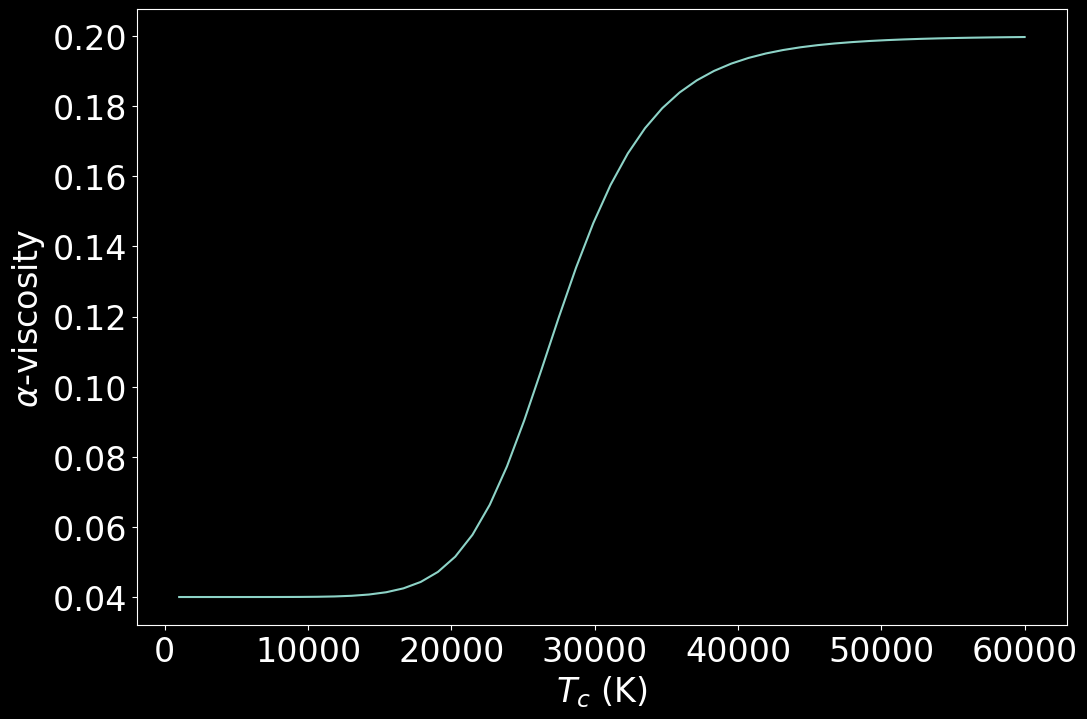

In [7]:
def plot_alpha2(T_c, alpha_v, T_2, alpha_2):
    plt.figure(figsize=(12, 8))
    plt.plot(T_c, alpha_v)
    plt.xlabel('$T_c$ (K)')
    plt.ylabel(r'$\alpha$-viscosity')
    plt.show()

plot_alpha2(example_Tc, example_al, example_Tc, a2)

    ![png](../../graphs/output_6_0.png)    